<a href="https://colab.research.google.com/github/annavarapunavya/annavarapunavya/blob/main/Diabeties_predicion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#Importing dataset
dataset = pd.read_csv('diabetes.csv')
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Text(0.5, 1.0, 'corelation Heat Map')

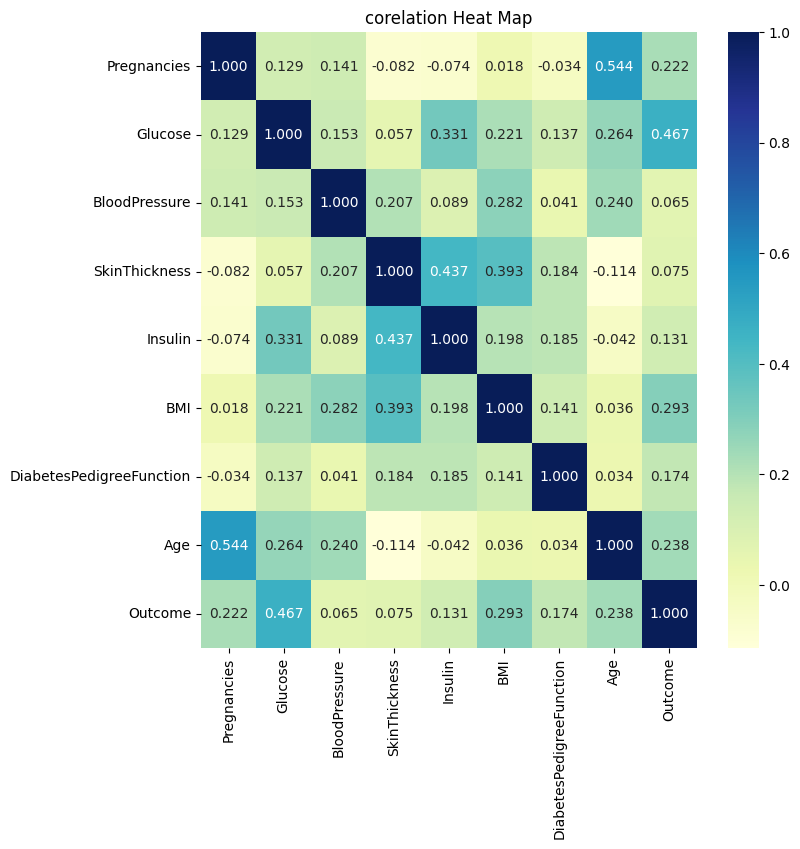

In [6]:
#Corelation plot of independent variables
plt.figure(figsize=(8,8))
sns.heatmap(dataset.corr(),annot=True,fmt=".3f",cmap="YlGnBu")
plt.title("corelation Heat Map")

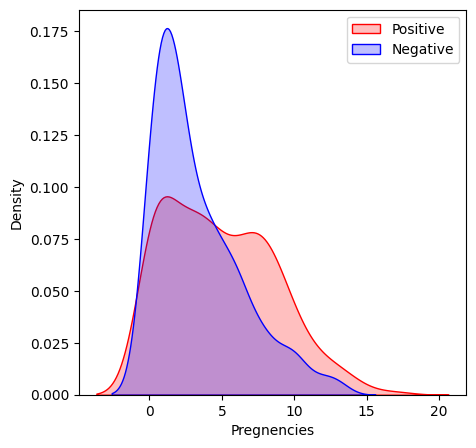

In [7]:
#Explorinig pregnency and target varibales
plt.figure(figsize=(5,5))
#Plotting density functioin graph of pregnencies and target variables
kde=sns.kdeplot(dataset['Pregnancies'][dataset['Outcome']==1],color='red',fill=True)
kde=sns.kdeplot(dataset['Pregnancies'][dataset['Outcome']==0],color='blue',fill=True)
kde.set_xlabel('Pregnencies')
kde.set_ylabel('Density')
kde.legend(["Positive","Negative"])

<Axes: xlabel='Outcome', ylabel='Glucose'>

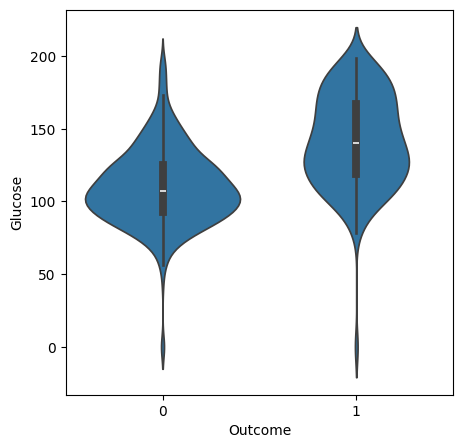

In [8]:
#Exploring glucose and target varibles
plt.figure(figsize=(5,5))
sns.violinplot(data=dataset,x='Outcome',y='Glucose')


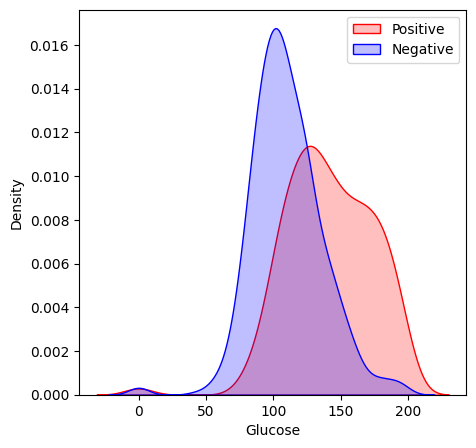

In [9]:
#Explorinig Glucose and target varibales
plt.figure(figsize=(5,5))
#Plotting density functioin graph of pregnencies and target variables
kde=sns.kdeplot(dataset['Glucose'][dataset['Outcome']==1],color='red',fill=True)
kde=sns.kdeplot(dataset['Glucose'][dataset['Outcome']==0],color='blue',fill=True)
kde.set_xlabel('Glucose')
kde.set_ylabel('Density')
kde.legend(["Positive","Negative"])

In [10]:
#Replacing 0 values with mean/median of the respective feature
#Glucose
dataset['Glucose']=dataset['Glucose'].replace(0,dataset['Glucose'].mean())
#Blood pressure
dataset['BloodPressure']=dataset['BloodPressure'].replace(0,dataset['BloodPressure'].mean())
#Skin thickness
dataset['SkinThickness']=dataset['SkinThickness'].replace(0,dataset['SkinThickness'].mean())
#BMI
dataset['BMI']=dataset['BMI'].replace(0,dataset['BMI'].mean())
#Insulin
dataset['Insulin']=dataset['Insulin'].replace(0,dataset['Insulin'].mean())


In [11]:
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [12]:
#Splitting dependent and independent variables
x=dataset.drop('Outcome',axis=1)
y=dataset['Outcome']

In [13]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63
764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27
765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30
766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47


In [14]:
#splitting the dataset into training and testing dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
#knn
from sklearn.neighbors import KNeighborsClassifier
training_accuracy=[]
testing_accuracy=[]
for n_neighbors in range(1,11):
    knn=KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(x_train,y_train)
    training_accuracy.append(knn.score(x_train,y_train))
    testing_accuracy.append(knn.score(x_test,y_test))


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

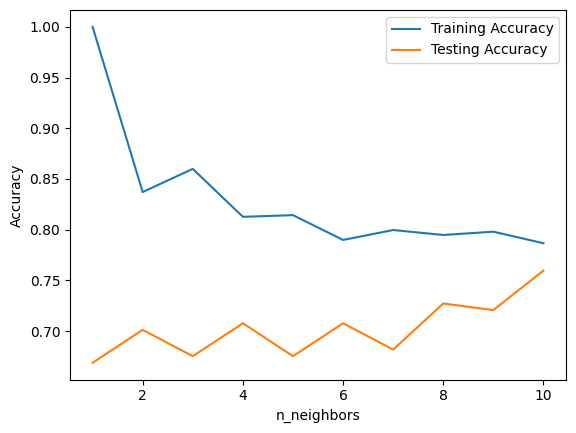

In [16]:
plt.plot(range(1,11),training_accuracy,label='Training Accuracy')
plt.plot(range(1,11),testing_accuracy,label='Testing Accuracy')
plt.legend()
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt

In [17]:
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train,y_train)
print(knn.score(x_train,y_train),":Traning Accuracy")
print(knn.score(x_test,y_test),":Testing Accuracy")

0.7866449511400652 :Traning Accuracy
0.7597402597402597 :Testing Accuracy


In [24]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
print(dt.score(x_train,y_train),":Traning Accuracy")
print(dt.score(x_test,y_test),":Testing Accuracy")

1.0 :Traning Accuracy
0.7272727272727273 :Testing Accuracy


In [25]:
dt1=DecisionTreeClassifier(max_depth= 5,class_weight='balanced')
dt1.fit(x_train,y_train)
print(dt1.score(x_train,y_train),":Traning Accuracy")
print(dt1.score(x_test,y_test),":Testing Accuracy")

0.8355048859934854 :Traning Accuracy
0.7597402597402597 :Testing Accuracy


In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [27]:
mlp1=MLPClassifier(random_state=42)
mlp1.fit(x_train,y_train)
print(mlp1.score(x_train,y_train),":Traning Accuracy")
print(mlp1.score(x_test,y_test),":Testing Accuracy")

0.8175895765472313 :Traning Accuracy
0.7467532467532467 :Testing Accuracy


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


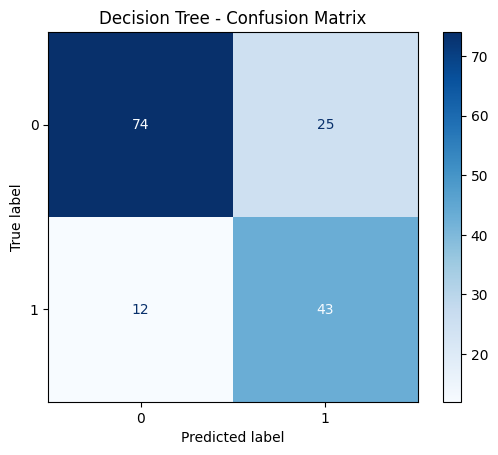

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_dt = dt1.predict(x_test)
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

